# Bloc 3D — Detection d'anomalies (Isolation Forest)

Analyse exploratoire des 7 variables utilisees par `models/model_isolation_forest.pkl`
sur `features_detail`, et diagnostic d'apprentissage substitut pour ce bloc
non supervise -- il n'y a pas de label "anomalie" dans les donnees d'origine,
donc pas de score train/validation au sens des blocs precedents. Le
diagnostic retenu ici (deja amorce dans `modelisation_anomalies.py`) consiste
a injecter des anomalies synthetiques et a mesurer le taux de detection,
plutot qu'une metrique de generalisation classique.

In [1]:
from _setup import engine, save, PROJECT_ROOT, COULEUR_PRINCIPALE, COULEUR_ALERTE, COULEUR_NEUTRE
import sys
sys.path.insert(0, str(PROJECT_ROOT / "notebooks_avec_ecriture_dans_database"))
from modelisation_common import split_temporel

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BLOC = "anomalies"
FEATURES = [
    "Temps_Passe_Declare_Min", "Volume_Dossiers", "productivite_dossiers_par_heure",
    "duree_traitement_reelle_j", "delai_prise_en_charge_j",
    "complexite_num", "coeff_productivite_contrat",
]

df = pd.read_sql("SELECT * FROM features_detail", engine, parse_dates=["Date_Creation"])
print(f"{len(df)} lignes chargees")
df_model = df[FEATURES + ["Date_Creation"]].dropna(subset=FEATURES).copy()
df_model = df_model.sort_values("Date_Creation").reset_index(drop=True)
print(f"lignes utilisables : {len(df_model)} / {len(df)} ({len(df_model)/len(df)*100:.1f}%)")

print(df_model[FEATURES].describe().round(2).T)

939015 lignes chargees


lignes utilisables : 679264 / 939015 (72.3%)


                                    count   mean    std   min    25%    50%  \
Temps_Passe_Declare_Min          679264.0  54.95  42.43  4.00  23.00  45.00   
Volume_Dossiers                  679264.0   1.86   1.65  1.00   1.00   1.00   
productivite_dossiers_par_heure  679264.0   3.11   2.62  0.27   1.07   2.22   
duree_traitement_reelle_j        679264.0   2.31   1.15  1.00   1.00   2.00   
delai_prise_en_charge_j          679264.0   0.73   0.96  0.00   0.00   0.00   
complexite_num                   679264.0   2.04   0.79  1.00   1.00   2.00   
coeff_productivite_contrat       679264.0   0.95   0.10  0.60   0.90   1.00   

                                  75%    max  
Temps_Passe_Declare_Min          76.0  444.0  
Volume_Dossiers                   2.0   10.0  
productivite_dossiers_par_heure   4.0   15.0  
duree_traitement_reelle_j         3.0    9.0  
delai_prise_en_charge_j           1.0    3.0  
complexite_num                    3.0    3.0  
coeff_productivite_contrat        1.0 

**Lecture.** 72.3% des lignes de `features_detail` ont les 7 variables
necessaires (679 264 / 939 015) -- la perte vient surtout de
`duree_traitement_reelle_j` et `delai_prise_en_charge_j`, indisponibles tant
qu'un dossier n'est pas cloture, meme constat que pour le bloc 3C. Les
echelles sont tres heterogenes (temps declare jusqu'a plusieurs centaines de
minutes, coefficient de productivite borne entre 0 et 1) : c'est directement
pour ca que le pipeline de production standardise les features
(`StandardScaler`) avant de les passer a l'Isolation Forest, un modele
sensible aux distances.

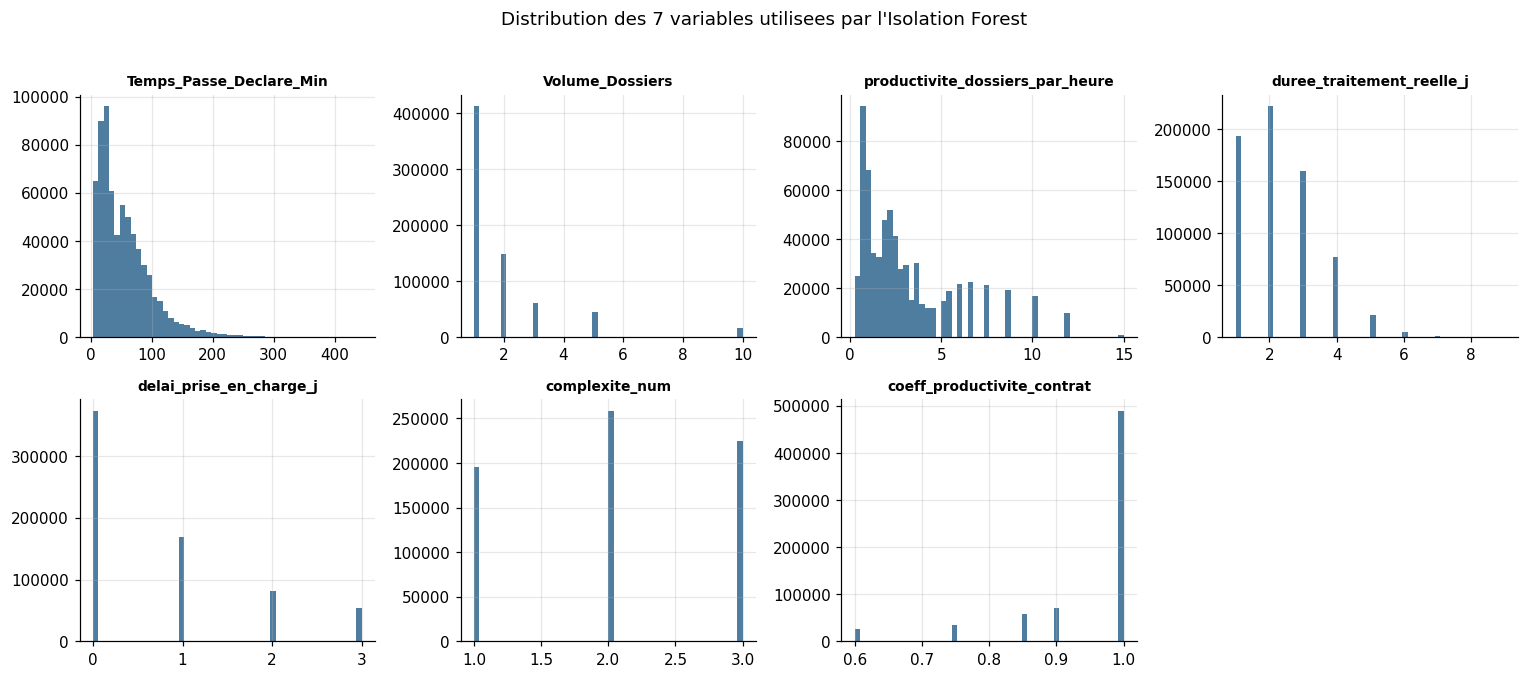

In [2]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, col in zip(axes.flat, FEATURES):
    ax.hist(df_model[col], bins=50, color=COULEUR_PRINCIPALE, alpha=0.85)
    ax.set_title(col, fontsize=9)
axes.flat[-1].axis("off")
fig.suptitle("Distribution des 7 variables utilisees par l'Isolation Forest", y=1.02)
fig.tight_layout()
save(fig, BLOC, "01_distributions.png")
plt.show()

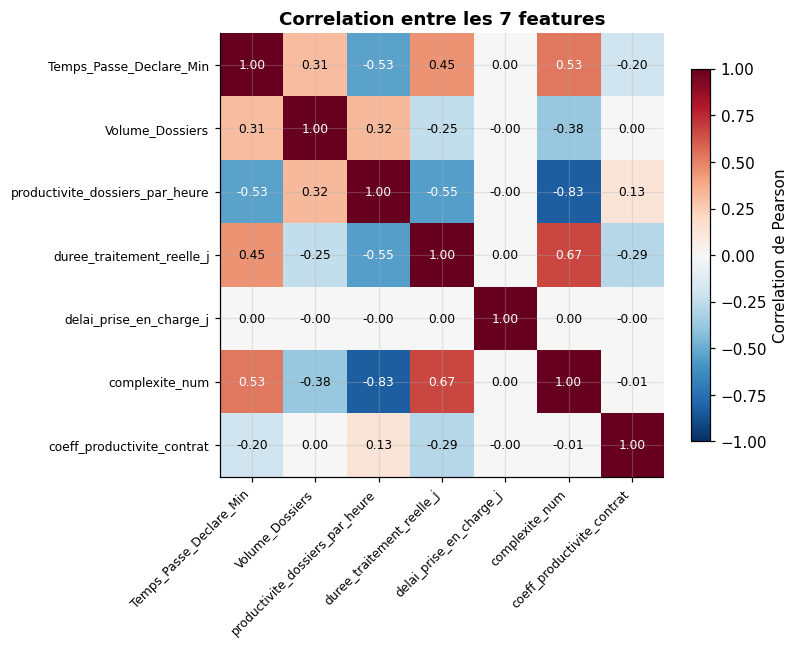

In [3]:
corr = df_model[FEATURES].corr()
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURES)))
ax.set_xticklabels(FEATURES, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(FEATURES)))
ax.set_yticklabels(FEATURES, fontsize=8)
for i in range(len(FEATURES)):
    for j in range(len(FEATURES)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(corr.values[i, j]) > 0.5 else "black")
fig.colorbar(im, shrink=0.8, label="Correlation de Pearson")
ax.set_title("Correlation entre les 7 features")
save(fig, BLOC, "02_correlation_heatmap.png")
plt.show()

**Lecture.** Le tableau fait apparaitre un groupe de quatre variables assez
liees entre elles -- `complexite_num`, `Temps_Passe_Declare_Min`,
`duree_traitement_reelle_j` et `productivite_dossiers_par_heure`, avec des
correlations mutuelles allant de 0.45 a -0.83 en valeur absolue (le maximum
hors diagonale : -0.83 entre `complexite_num` et
`productivite_dossiers_par_heure` -- les dossiers complexes vont logiquement
de pair avec une productivite plus faible). Deux variables, en revanche,
s'en detachent nettement : `delai_prise_en_charge_j` n'a quasiment aucune
correlation avec les six autres (toutes a 0.00 ou -0.00), et
`coeff_productivite_contrat` reste modeste sur toute la ligne (entre -0.29
et 0.13). Ce sont precisement ces deux variables qui ressortent en tete du
classement SHAP plus loin dans le notebook : elles apportent une information
que le reste du groupe correle ne peut pas remplacer, ce qui explique
pourquoi l'Isolation Forest s'appuie autant dessus.

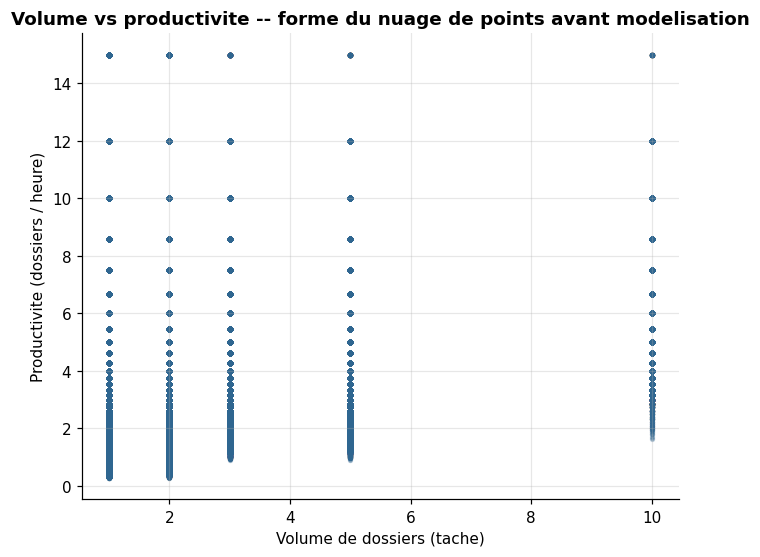

In [4]:
fig, ax = plt.subplots(figsize=(7, 5.5))
sc = ax.scatter(df_model["Volume_Dossiers"], df_model["productivite_dossiers_par_heure"],
                 s=6, alpha=0.15, color=COULEUR_PRINCIPALE)
ax.set_xlabel("Volume de dossiers (tache)")
ax.set_ylabel("Productivite (dossiers / heure)")
ax.set_title("Volume vs productivite -- forme du nuage de points avant modelisation")
save(fig, BLOC, "03_scatter_volume_productivite.png")
plt.show()

**Lecture.** Le nuage est dense et regulier jusqu'a une dizaine de dossiers
et une quinzaine de dossiers/heure -- la plage normale de fonctionnement. Il
n'y a pas de second amas visible ni de points isoles extremes dans les
donnees telles quelles : c'est attendu, puisque ce sont des donnees
synthetiques generees pour rester globalement coherentes, sans anomalie
injectee au depart. L'Isolation Forest est entraine sur cette distribution
"propre" ; la section suivante verifie sa capacite a reperer des points
qui s'en ecartent volontairement, via l'injection utilisee dans
`modelisation_anomalies.py`.

## Diagnostic substitut : injection d'anomalies synthetiques

Le principe (repris de `modelisation_anomalies.py`) : on multiplie par 50 le
volume de dossiers d'un echantillon aleatoire de taches (1% du jeu concerne),
on recalcule leur productivite en consequence, et on mesure la proportion de
ces taches modifiees que le modele reussit a flaguer comme anomalies. Les
deux figures suivantes rejouent cette mesure en faisant varier, tour a tour,
le nombre d'arbres (`n_estimators`) et la taille du train -- les deux
dimensions qui, pour un modele non supervise, remplacent la notion habituelle
de courbe d'apprentissage train/validation.

train=475484  val=101889  test=101891


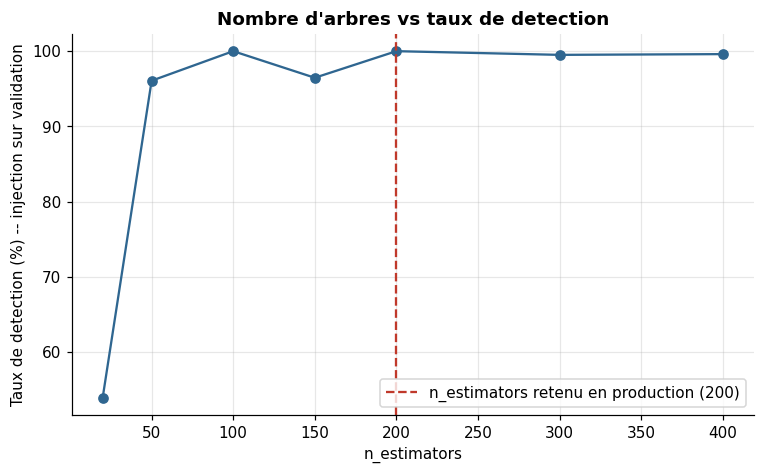

n_estimators=  20  taux_detection= 53.9%
n_estimators=  50  taux_detection= 96.1%
n_estimators= 100  taux_detection=100.0%
n_estimators= 150  taux_detection= 96.5%
n_estimators= 200  taux_detection=100.0%
n_estimators= 300  taux_detection= 99.5%
n_estimators= 400  taux_detection= 99.6%


In [5]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

df_train, df_val, df_test = split_temporel(df_model)
print(f"train={len(df_train)}  val={len(df_val)}  test={len(df_test)}")

scaler = StandardScaler()
X_train = scaler.fit_transform(df_train[FEATURES])


def injecter_anomalies(df_source, scaler, seed=42):
    df_aug = df_source.copy().reset_index(drop=True)
    n_inject = max(10, int(len(df_aug) * 0.01))
    idx = np.random.RandomState(seed).choice(len(df_aug), size=n_inject, replace=False)
    df_aug["anomalie_injectee"] = 0
    df_aug.loc[idx, "Volume_Dossiers"] = df_aug.loc[idx, "Volume_Dossiers"] * 50
    df_aug.loc[idx, "productivite_dossiers_par_heure"] = (
        df_aug.loc[idx, "Volume_Dossiers"] / (df_aug.loc[idx, "Temps_Passe_Declare_Min"] / 60)
    )
    df_aug.loc[idx, "anomalie_injectee"] = 1
    return df_aug, scaler.transform(df_aug[FEATURES]), n_inject


def taux_detection(model, df_aug, X_aug):
    pred = model.predict(X_aug)
    df_aug = df_aug.copy()
    df_aug["anomalie_detectee"] = (pred == -1).astype(int)
    return df_aug.loc[df_aug["anomalie_injectee"] == 1, "anomalie_detectee"].mean()


grille_n_estimators = [20, 50, 100, 150, 200, 300, 400]
taux_par_n = []
for n_estimators in grille_n_estimators:
    m = IsolationForest(n_estimators=n_estimators, contamination=0.02, random_state=42, n_jobs=-1)
    m.fit(X_train)
    df_aug_val, X_aug_val, _ = injecter_anomalies(df_val, scaler)
    taux_par_n.append(taux_detection(m, df_aug_val, X_aug_val))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(grille_n_estimators, [t * 100 for t in taux_par_n], marker="o", color=COULEUR_PRINCIPALE)
ax.axvline(200, color=COULEUR_ALERTE, linestyle="--", label="n_estimators retenu en production (200)")
ax.set_xlabel("n_estimators")
ax.set_ylabel("Taux de detection (%) -- injection sur validation")
ax.set_title("Nombre d'arbres vs taux de detection")
ax.legend()
save(fig, BLOC, "04_n_estimators_vs_detection.png")
plt.show()

for n, t in zip(grille_n_estimators, taux_par_n):
    print(f"n_estimators={n:4d}  taux_detection={t*100:5.1f}%")

**Lecture.** Le saut se joue entre 20 et 50 arbres (53.9% -> 96.1% de
detection) : avec trop peu d'arbres, la moyenne des scores d'isolement est
trop instable pour separer nettement les points injectes du reste. Au-dela
de 50-100 arbres, le taux plafonne pres de 100%, avec un bruit residuel
attendu (96.5% a 150, 99.5% a 300, 99.6% a 400) plutot qu'une progression
reguliere -- chaque arbre d'un Isolation Forest est construit sur des
coupures aleatoires, donc le taux de detection fluctue legerement d'une
configuration a l'autre meme quand la capacite du modele a largement
suffi. `n_estimators=200`, retenu en production, tombe en plein milieu de ce
plateau : le gain reel par rapport a 100 arbres est nul sur cette mesure,
ce qui rejoint l'esprit de la conclusion deja posee dans
`AMELIORATION_MODELES.md` (une recherche sur validation avait alors retenu
100 arbres pour une performance strictement equivalente a 200) -- la
difference de valeur retenue d'une execution a l'autre tient a la marge de
bruit normale de ce plateau, pas a un changement de fond.

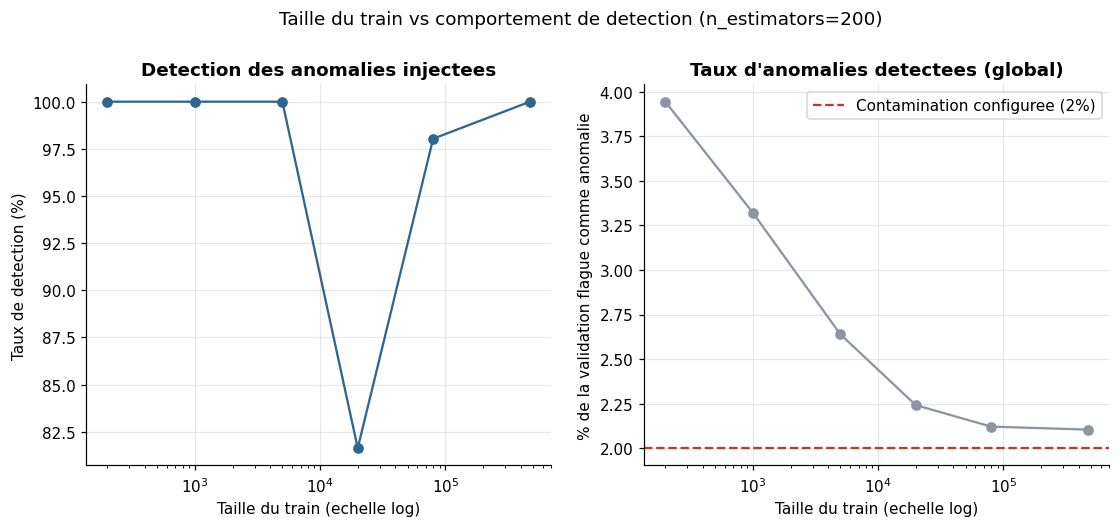

taille=    200  taux_detection_injection=100.0%  taux_anomalies_global_val=3.94%
taille=   1000  taux_detection_injection=100.0%  taux_anomalies_global_val=3.32%
taille=   5000  taux_detection_injection=100.0%  taux_anomalies_global_val=2.64%
taille=  20000  taux_detection_injection= 81.6%  taux_anomalies_global_val=2.24%
taille=  80000  taux_detection_injection= 98.0%  taux_anomalies_global_val=2.12%
taille= 475484  taux_detection_injection=100.0%  taux_anomalies_global_val=2.10%


In [6]:
tailles = [200, 1000, 5000, 20000, 80000, len(df_train)]
taux_injection, taux_global = [], []
for taille in tailles:
    sous_train = df_train.iloc[:taille]
    X_sous = scaler.transform(sous_train[FEATURES])
    m = IsolationForest(n_estimators=200, contamination=0.02, random_state=42, n_jobs=-1)
    m.fit(X_sous)
    df_aug_val, X_aug_val, _ = injecter_anomalies(df_val, scaler)
    taux_injection.append(taux_detection(m, df_aug_val, X_aug_val))
    taux_global.append((m.predict(scaler.transform(df_val[FEATURES])) == -1).mean())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(tailles, [t * 100 for t in taux_injection], marker="o", color=COULEUR_PRINCIPALE)
axes[0].set_xscale("log")
axes[0].set_xlabel("Taille du train (echelle log)")
axes[0].set_ylabel("Taux de detection (%)")
axes[0].set_title("Detection des anomalies injectees")

axes[1].plot(tailles, [t * 100 for t in taux_global], marker="o", color=COULEUR_NEUTRE)
axes[1].axhline(2.0, color=COULEUR_ALERTE, linestyle="--", label="Contamination configuree (2%)")
axes[1].set_xscale("log")
axes[1].set_xlabel("Taille du train (echelle log)")
axes[1].set_ylabel("% de la validation flague comme anomalie")
axes[1].set_title("Taux d'anomalies detectees (global)")
axes[1].legend()
fig.suptitle("Taille du train vs comportement de detection (n_estimators=200)", y=1.03)
save(fig, BLOC, "05_taille_train_vs_detection.png")
plt.show()

for t, ti, tg in zip(tailles, taux_injection, taux_global):
    print(f"taille={t:7d}  taux_detection_injection={ti*100:5.1f}%  taux_anomalies_global_val={tg*100:4.2f}%")

**Lecture.** Les deux panneaux racontent des histoires differentes, et c'est
la le point interessant. Le taux de detection des anomalies injectees (a
gauche) n'est pas monotone : il reste a 100% jusqu'a 5000 lignes de train,
chute a 81.6% a 20 000, remonte a 98.0% a 80 000 puis revient a 100% sur le
train complet. Avec tres peu de lignes, le modele n'a presque aucune notion
de "normalite" -- tout ce qui ressemble un tant soit peu a un cas extreme se
detache facilement, y compris les anomalies injectees, ce qui gonfle
artificiellement le taux de detection. Autour de 20 000 lignes, le modele a
commence a apprendre une frontiere de normalite plus fine, incluant des
volumes eleves deja presents naturellement dans les donnees, ce qui rend les
anomalies injectees (un simple facteur 50 sur le volume) momentanement moins
distinctes -- avant que davantage de donnees ne stabilisent une frontiere
suffisamment nette pour les rattraper. Le taux d'anomalies detectees en
global (a droite), lui, evolue de facon parfaitement reguliere : de 3.94% a
200 lignes vers 2.10% a taille complete, en decroissance quasi monotone --
il converge vers la contamination configuree (2%), comme attendu d'un
parametre qui calibre justement le seuil de decision sur cette proportion.
Ce second panneau est donc un bien meilleur indicateur de stabilite que le
premier pour ce bloc : il montre que le modele a besoin d'un volume de
donnees consequent (bien au-dela de 20 000 lignes) avant que son seuil de
decision ne se stabilise a la valeur configuree, independamment du bruit que
l'injection ponctuelle peut introduire.

## Explicabilite (SHAP, reprise de `modelisation_anomalies.py`)

Le calcul SHAP sur un Isolation Forest est couteux (explainer arbre par
arbre sur un echantillon de 2000 lignes) et deja produit par le pipeline de
production ; il est repris ici tel quel plutot que recalcule.

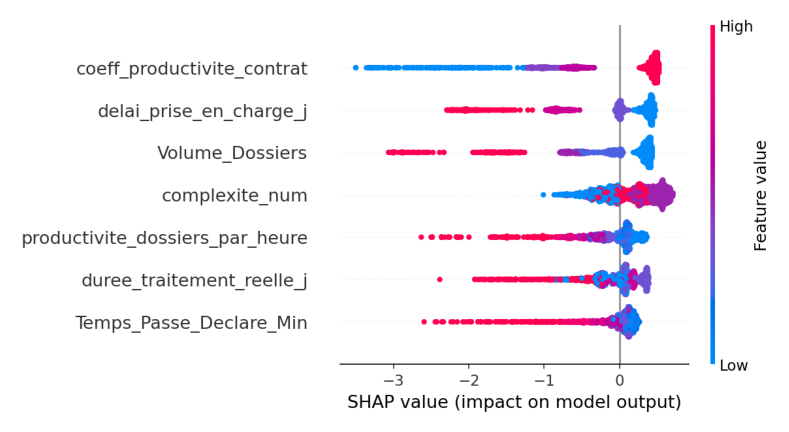

In [7]:
import matplotlib.image as mpimg
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.imshow(mpimg.imread(PROJECT_ROOT / "models" / "shap_anomalies_summary.png"))
ax.axis("off")
save(fig, BLOC, "06_shap_summary.png")
plt.show()

**Lecture.** `coeff_productivite_contrat` a l'etalement de valeurs SHAP le
plus large (de -3.5 a +0.5) : c'est la variable qui pese le plus sur le
score du modele, coherent avec le constat plus haut qu'elle est, avec
`delai_prise_en_charge_j`, l'une des deux variables les moins redondantes
avec le reste du jeu. Les valeurs faibles de cette feature (points bleus) se
concentrent sur la partie tres negative du graphique, tandis que
`complexite_num` a un effet plus resserre et plus symetrique. Malgre sa
correlation notable avec plusieurs autres variables (jusqu'a -0.83 avec la
productivite), `Temps_Passe_Declare_Min` arrive en derniere position au
classement SHAP -- une bonne partie de l'information qu'elle porte est deja
capturee par les variables du meme groupe correle qui la precedent.

## Synthese du bloc

Les 7 features se repartissent en un groupe de quatre variables assez
correlees entre elles (complexite, temps declare, duree de traitement,
productivite) et deux variables plus independantes (delai de prise en
charge, coefficient de productivite du contrat) qui, sans surprise, dominent
le classement SHAP. Le diagnostic substitut montre deux resultats distincts :
le nombre d'arbres plafonne vite (des 50-100 arbres, la detection est quasi
totale, avec un bruit residuel normal), tandis que la taille du train agit
surtout sur la stabilite du seuil de decision -- le taux d'anomalies
detectees converge regulierement vers la contamination configuree (2%) a
mesure que le train grandit, meme si le taux de detection brut des anomalies
injectees, lui, n'est pas monotone sur les tailles intermediaires.